# Fault Detection (Anomaly) Notebook

This notebook follows the `new.ipynb` feature pipeline and uses the public dataset from
`autoencoder_public.ipynb`. We treat **FAN_ON** as *normal* and all other faults as *anomalies*,
then compare three detection methods.

In [17]:
# Enable autoreload so edits to modules are picked up without restarting the kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
from pathlib import Path
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support
from sklearn.svm import SVC, OneClassSVM
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import mutual_info_classif

# Project root so we can import fdd_system/experiment modules
root = str(Path.cwd().parent)
if root not in sys.path:
    sys.path.append(root)
print("Root:", root)

from experiment.utils import prepare_training_data
from fdd_system.ML.common.preprocessor import DummyPreprocessor
from fdd_system.ML.common.embedder import MLEmbedder2, MLEmbedder1

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# Torch reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


Root: /home/btanady/fourth_year/cpen491


In [19]:
from fdd_system.ML.common.config import OperatingCondition

# data_13 layout: normal/blocked/interfere
DATA_PATH = Path("test_2")
if not DATA_PATH.exists():
    DATA_PATH = Path("experiment/data_13")

if not DATA_PATH.exists():
    raise FileNotFoundError("data_13 not found. Expected at experiment/data_13 or ./data_13")

REMOVE_FIRST_SECOND = 2


# Split ratios (train/val/test)
TRAIN_RATIO = 0.6
VAL_RATIO = 0.2
TEST_RATIO = 0.2
TOTAL_RATIO = TRAIN_RATIO + VAL_RATIO + TEST_RATIO
if abs(TOTAL_RATIO - 1.0) > 1e-6:
    raise ValueError(f"Train/val/test ratios must sum to 1.0, got {TOTAL_RATIO}")
TRAIN_VAL_RATIO = TRAIN_RATIO + VAL_RATIO
VAL_SPLIT = VAL_RATIO / TRAIN_VAL_RATIO  # fraction of train+val used for val

normal_path = DATA_PATH / "normal"
blocked_path = DATA_PATH / "blocked"
interfere_path = DATA_PATH / "interfere"

NORMAL_FILES = sorted([str(p) for p in normal_path.glob("*.csv")])
BLOCKED_FILES = sorted([str(p) for p in blocked_path.glob("*.csv")])
INTERFERE_FILES = sorted([str(p) for p in interfere_path.glob("*.csv")]) if interfere_path.exists() else []

buckets = {
    "normal": NORMAL_FILES,
    "blocked": BLOCKED_FILES,
    "interfere": INTERFERE_FILES,
}

LABELS = {
    "normal": OperatingCondition.NORMAL.value,
    "blocked": OperatingCondition.BLOCKED_AIRFLOW.value,
    "interfere": OperatingCondition.BLADE_ISSUE.value,
}
LABEL_NAMES = {v: k for k, v in LABELS.items()}
NORMAL_LABEL = LABELS["normal"]

for k, v in buckets.items():
    print(f"{k:10s}: {len(v)} files")


normal    : 10 files
blocked   : 10 files
interfere : 10 files


In [20]:
# File-level splits to avoid window overlap leakage
normal_files = sorted(buckets["normal"])
blocked_files = sorted(buckets["blocked"])

if not normal_files:
    raise FileNotFoundError("No NORMAL files found under data_13/normal")
if not blocked_files:
    raise FileNotFoundError("No BLOCKED files found under data_13/blocked")

normal_trainval, normal_test = train_test_split(
    normal_files, test_size=TEST_RATIO, shuffle=True, random_state=SEED
)
normal_train, normal_val = train_test_split(
    normal_trainval, test_size=VAL_SPLIT, shuffle=True, random_state=SEED
)

blocked_trainval, blocked_test = train_test_split(
    blocked_files, test_size=TEST_RATIO, shuffle=True, random_state=SEED
)
blocked_train, blocked_val = train_test_split(
    blocked_trainval, test_size=VAL_SPLIT, shuffle=True, random_state=SEED
)

print(f"normal: train={len(normal_train)}, val={len(normal_val)}, test={len(normal_test)}")
print(f"blocked: train={len(blocked_train)}, val={len(blocked_val)}, test={len(blocked_test)}")

print("Test counts:")
print(f"  normal={len(normal_test)}")
print(f"  blocked={len(blocked_test)}")


normal: train=6, val=2, test=2
blocked: train=6, val=2, test=2
Test counts:
  normal=2
  blocked=2


In [21]:
from fdd_system.ML.common.preprocessor import *
# Window the raw CSVs into RawAccWindow objects
COLS = ["X", "Y", "Z"]

train_files = {
    LABELS["normal"]: normal_train,
    LABELS["blocked"]: blocked_train,
}
val_files = {
    LABELS["normal"]: normal_val,
    LABELS["blocked"]: blocked_val,
}

train_data = prepare_training_data(
    train_files, shuffle=True, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
)
val_data = prepare_training_data(
    val_files, shuffle=False, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
)

test_normal_data = prepare_training_data(
    {LABELS["normal"]: normal_test}, shuffle=False, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
)
test_blocked_data = prepare_training_data(
    {LABELS["blocked"]: blocked_test}, shuffle=False, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
)

test_fault_data = {}
if buckets["interfere"]:
    test_fault_data["interfere"] = prepare_training_data(
        {LABELS["interfere"]: buckets["interfere"]},
        shuffle=False,
        col_names=COLS,
        remove_first_second=REMOVE_FIRST_SECOND,
    )

# Light preprocessing (no-op, matches new.ipynb default)
RMSNorm = RMSNormalization
pre = RMSNorm()
train_pre = pre.preprocess(train_data)
val_pre = pre.preprocess(val_data)

test_normal_pre = pre.preprocess(test_normal_data)
test_blocked_pre = pre.preprocess(test_blocked_data)
for fault_name in list(test_fault_data.keys()):
    test_fault_data[fault_name] = pre.preprocess(test_fault_data[fault_name])

print(
    f"windows: train={len(train_pre)}, val={len(val_pre)}, test_normal={len(test_normal_pre)}, test_blocked={len(test_blocked_pre)}"
)
for fault_name, windows in test_fault_data.items():
    print(f"windows: test_{fault_name}={len(windows)}")


windows: train=472, val=157, test_normal=78, test_blocked=78
windows: test_interfere=390


In [22]:
# Feature extraction (matches new.ipynb pipeline)
embedder = MLEmbedder2()

X_train = embedder.embed(train_pre)
X_val = embedder.embed(val_pre)
X_test_normal = embedder.embed(test_normal_pre)
X_test_blocked = embedder.embed(test_blocked_pre)
X_test_faults = {
    name: embedder.embed(windows) for name, windows in test_fault_data.items()
}

y_train = np.array([w.label for w in train_pre], dtype=int)
y_val = np.array([w.label for w in val_pre], dtype=int)
y_test_normal = np.array([w.label for w in test_normal_pre], dtype=int)
y_test_blocked = np.array([w.label for w in test_blocked_pre], dtype=int)
FEATURE_SELECTION = False
METHOD = "fisher"  # fisher | mi
TOP_FEATURE_RATIO = 0.3  # keep top fraction of features


def fisher_score(X, y, eps=1e-12):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y)
    classes = np.unique(y)
    overall_mean = np.mean(X, axis=0)
    num = np.zeros(X.shape[1], dtype=float)
    den = np.zeros(X.shape[1], dtype=float)
    for cls in classes:
        Xc = X[y == cls]
        if Xc.size == 0:
            continue
        n_c = Xc.shape[0]
        mu_c = np.mean(Xc, axis=0)
        var_c = np.var(Xc, axis=0)
        num += n_c * (mu_c - overall_mean) ** 2
        den += n_c * var_c
    scores = num / (den + eps)
    return scores


def select_features(X, y, method="fisher", ratio=0.25):
    n_features = X.shape[1]
    k = max(1, int(np.ceil(ratio * n_features)))
    method = method.lower()
    if method == "fisher":
        scores = fisher_score(X, y)
    elif method == "mi":
        scores = mutual_info_classif(X, y, random_state=SEED)
    else:
        raise ValueError(f"Unknown METHOD: {method}")
    idx = np.argsort(scores)[-k:]
    return idx, scores


# Optional: feature selection (train only)
if FEATURE_SELECTION:
    X_train_np = np.asarray(X_train)
    y_train_np = np.asarray(y_train)

    top_idx, scores = select_features(X_train_np, y_train_np, method=METHOD, ratio=TOP_FEATURE_RATIO)
    print(f"Selected top {len(top_idx)}/{X_train_np.shape[1]} features by {METHOD}")

    X_train = X_train_np[:, top_idx]
    X_val = np.asarray(X_val)[:, top_idx]
    X_test_normal = np.asarray(X_test_normal)[:, top_idx]
    X_test_blocked = np.asarray(X_test_blocked)[:, top_idx]
    X_test_faults = {name: np.asarray(X)[:, top_idx] for name, X in X_test_faults.items()}


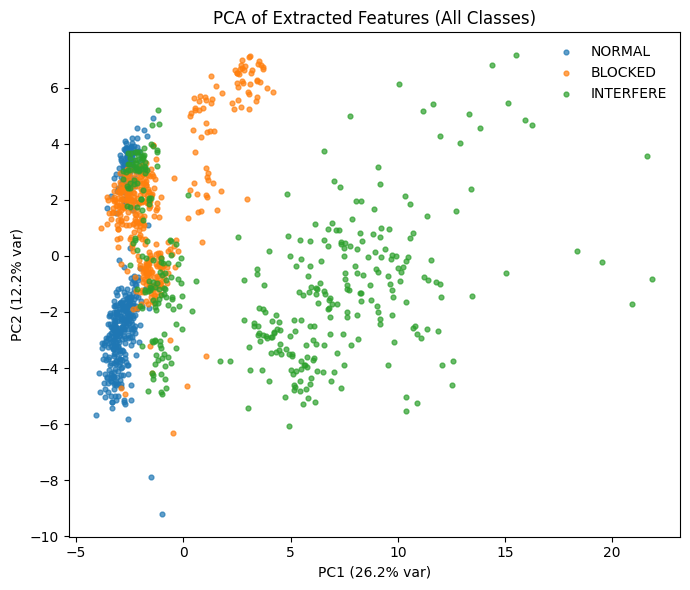

In [23]:
# PCA plot for all extracted features (2D)
DISPLAY_NAMES = {
    "normal": "NORMAL",
    "blocked": "BLOCKED",
    "interfere": "INTERFERE",
}

X_all = [X_train, X_val, X_test_normal, X_test_blocked]
y_all = [y_train, y_val, y_test_normal, y_test_blocked]
for fault_name, X_fault in X_test_faults.items():
    X_all.append(X_fault)
    y_all.append(np.full(len(X_fault), LABELS[fault_name], dtype=int))

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)

scaler_all = StandardScaler().fit(X_all)
X_all_scaled = scaler_all.transform(X_all)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_all_scaled)

plt.figure(figsize=(7, 6))
for lbl in sorted(np.unique(y_all)):
    m = y_all == lbl
    name = LABEL_NAMES.get(int(lbl), str(lbl))
    plt.scatter(Z[m, 0], Z[m, 1], s=12, alpha=0.7, label=DISPLAY_NAMES.get(name, name))

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA of Extracted Features (All Classes)")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


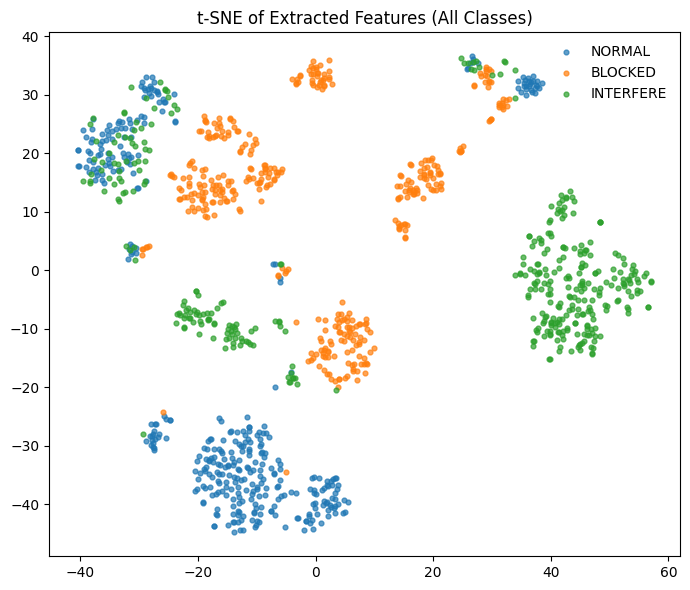

In [24]:
# t-SNE plot for all extracted features (2D)
# Note: t-SNE is stochastic; adjust perplexity or random_state for stability

TSNE_PERPLEXITY = 30
TSNE_LEARNING_RATE = 200
TSNE_N_ITER = 1000

X_all_scaled = scaler_all.transform(X_all)

# Guard against very small datasets (perplexity < n_samples)
perplexity = min(TSNE_PERPLEXITY, max(5, (len(X_all_scaled) - 1) // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate=TSNE_LEARNING_RATE,
    max_iter=TSNE_N_ITER,
    random_state=SEED,
    init='pca',
)
Z_tsne = tsne.fit_transform(X_all_scaled)

plt.figure(figsize=(7, 6))
for lbl in sorted(np.unique(y_all)):
    m = y_all == lbl
    name = LABEL_NAMES.get(int(lbl), str(lbl))
    plt.scatter(Z_tsne[m, 0], Z_tsne[m, 1], s=12, alpha=0.7, label=DISPLAY_NAMES.get(name, name))

plt.title('t-SNE of Extracted Features (All Classes)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [25]:
# Helper utilities for anomaly evaluation

def make_binary_labels(y, normal_label=NORMAL_LABEL):
    return (y != normal_label).astype(int)


def stack_test_sets():
    X_parts = [X_test_normal, X_test_blocked]
    y_parts = [y_test_normal, y_test_blocked]
    for fault_name, X_fault in X_test_faults.items():
        X_parts.append(X_fault)
        y_parts.append(np.full(len(X_fault), LABELS[fault_name], dtype=int))
    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)
    return X, y


def find_best_threshold(scores, y_true, n_grid=200, anomaly_if_low=True):
    qs = np.linspace(0, 1, n_grid)
    thresholds = np.quantile(scores, qs)
    best_thr = thresholds[0]
    best_acc = -1.0
    for thr in thresholds:
        if anomaly_if_low:
            y_pred = (scores < thr).astype(int)
        else:
            y_pred = (scores > thr).astype(int)
        acc = accuracy_score(y_true, y_pred)
        if acc > best_acc:
            best_acc = acc
            best_thr = thr
    return float(best_thr), float(best_acc)


def eval_method(name, y_true, y_pred, group=None):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = float(fp) / float(fp + tn) if (fp + tn) > 0 else 0.0
    out = {
        "method": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "false_positive_rate": fpr,
    }
    if group is not None:
        out["group"] = group
    return out


In [26]:
# Method A: Train classifier on NORMAL vs BLOCKED; use NORMAL confidence for anomaly detection

CLASSIFIER = "lr"  # svm | lr
method_a_name = f"A: {CLASSIFIER.upper()} conf"

if CLASSIFIER.lower() == "svm":
    clf_a = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
    )
elif CLASSIFIER.lower() == "lr":
    clf_a = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    )
else:
    raise ValueError(f"Unknown CLASSIFIER: {CLASSIFIER}")

clf_a.fit(X_train, y_train)

# NORMAL confidence scores
normal_label = LABELS["normal"]
normal_idx = int(np.where(clf_a.named_steps["svc"].classes_ == normal_label)[0][0]) if CLASSIFIER.lower()=="svm" else int(np.where(clf_a.named_steps["logisticregression"].classes_ == normal_label)[0][0])

scores_val_a = clf_a.predict_proba(X_val)[:, normal_idx]
y_val_bin = make_binary_labels(y_val)

thr_a, val_acc_a = find_best_threshold(scores_val_a, y_val_bin, anomaly_if_low=True)
print(f"Method A threshold (val-optimized): {thr_a:.4f} | val_acc={val_acc_a:.3f}")

X_test, y_test = stack_test_sets()
y_test_bin = make_binary_labels(y_test)

scores_test_a = clf_a.predict_proba(X_test)[:, normal_idx]
y_pred_a = (scores_test_a < thr_a).astype(int)

print("Method A confusion matrix:", confusion_matrix(y_test_bin, y_pred_a))
print(classification_report(y_test_bin, y_pred_a, digits=3))


Method A threshold (val-optimized): 0.6262 | val_acc=0.968
Method A confusion matrix: [[ 78   0]
 [189 279]]
              precision    recall  f1-score   support

           0      0.292     1.000     0.452        78
           1      1.000     0.596     0.747       468

    accuracy                          0.654       546
   macro avg      0.646     0.798     0.600       546
weighted avg      0.899     0.654     0.705       546



In [27]:
# Method B: Distance to NORMAL centroid in feature space

# Fit scaler on NORMAL train only to avoid leakage
X_train_norm = X_train[y_train == NORMAL_LABEL]
X_val_norm = X_val[y_val == NORMAL_LABEL]

scaler_b = StandardScaler().fit(X_train_norm)
X_train_norm_s = scaler_b.transform(X_train_norm)
centroid = X_train_norm_s.mean(axis=0)


def dist_to_centroid(X):
    Xs = scaler_b.transform(X)
    return np.linalg.norm(Xs - centroid, axis=1)

# Threshold from NORMAL validation only (unsupervised)
DIST_Q = 0.95
val_dist_norm = dist_to_centroid(X_val_norm)
thr_b = float(np.quantile(val_dist_norm, DIST_Q))
print(f"Method B threshold (q={DIST_Q} on NORMAL val): {thr_b:.4f}")

# Test
X_test, y_test = stack_test_sets()
y_test_bin = make_binary_labels(y_test)

test_dist = dist_to_centroid(X_test)
y_pred_b = (test_dist > thr_b).astype(int)

print("Method B confusion matrix:", confusion_matrix(y_test_bin, y_pred_b))
print(classification_report(y_test_bin, y_pred_b, digits=3))

Method B threshold (q=0.95 on NORMAL val): 9.1662
Method B confusion matrix: [[  0  78]
 [  0 468]]
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        78
           1      0.857     1.000     0.923       468

    accuracy                          0.857       546
   macro avg      0.429     0.500     0.462       546
weighted avg      0.735     0.857     0.791       546



/home/btanady/fourth_year/cpen491/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/btanady/fourth_year/cpen491/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/btanady/fourth_year/cpen491/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [28]:
# Method F: SVDD (One-Class SVM) on NORMAL embeddings

SVDD_KERNEL = "rbf"
SVDD_NU = 0.05
SVDD_GAMMA = "scale"
SVDD_Q = 0.95  # quantile on NORMAL val decision scores

# Fit scaler on NORMAL train only to avoid leakage
X_train_norm = X_train[y_train == NORMAL_LABEL]
X_val_norm = X_val[y_val == NORMAL_LABEL]

scaler_f = StandardScaler().fit(X_train_norm)
X_train_norm_s = scaler_f.transform(X_train_norm)
X_val_norm_s = scaler_f.transform(X_val_norm)

X_test, y_test = stack_test_sets()
y_test_bin = make_binary_labels(y_test)
X_test_s = scaler_f.transform(X_test)

svdd = OneClassSVM(kernel=SVDD_KERNEL, nu=SVDD_NU, gamma=SVDD_GAMMA)
svdd.fit(X_train_norm_s)

val_scores_f = -svdd.decision_function(X_val_norm_s).ravel()
thr_f = float(np.quantile(val_scores_f, SVDD_Q))
print(f"Method F threshold (q={SVDD_Q} on NORMAL val): {thr_f:.4f}")

test_scores_f = -svdd.decision_function(X_test_s).ravel()
y_pred_f = (test_scores_f > thr_f).astype(int)

print("Method F confusion matrix:", confusion_matrix(y_test_bin, y_pred_f))
print(classification_report(y_test_bin, y_pred_f, digits=3))


Method F threshold (q=0.95 on NORMAL val): 0.1692
Method F confusion matrix: [[ 66  12]
 [ 47 421]]
              precision    recall  f1-score   support

           0      0.584     0.846     0.691        78
           1      0.972     0.900     0.935       468

    accuracy                          0.892       546
   macro avg      0.778     0.873     0.813       546
weighted avg      0.917     0.892     0.900       546



In [29]:
# Method C: Train a model on distance-to-centroid to output normal/fault

# Distances for train/val/test
train_dist = dist_to_centroid(X_train).reshape(-1, 1)
val_dist = dist_to_centroid(X_val).reshape(-1, 1)
test_dist = dist_to_centroid(X_test).reshape(-1, 1)

train_bin = make_binary_labels(y_train)
val_bin = make_binary_labels(y_val)

clf_c = LogisticRegression(class_weight="balanced", random_state=SEED)
clf_c.fit(train_dist, train_bin)

scores_val_c = clf_c.predict_proba(val_dist)[:, 1]
thr_c, val_acc_c = find_best_threshold(scores_val_c, val_bin, anomaly_if_low=False)
print(f"Method C threshold (val-optimized): {thr_c:.4f} | val_acc={val_acc_c:.3f}")

scores_test_c = clf_c.predict_proba(test_dist)[:, 1]
y_pred_c = (scores_test_c > thr_c).astype(int)

print("Method C confusion matrix:", confusion_matrix(y_test_bin, y_pred_c))
print(classification_report(y_test_bin, y_pred_c, digits=3))

Method C threshold (val-optimized): 0.4453 | val_acc=1.000
Method C confusion matrix: [[  5  73]
 [ 26 442]]
              precision    recall  f1-score   support

           0      0.161     0.064     0.092        78
           1      0.858     0.944     0.899       468

    accuracy                          0.819       546
   macro avg      0.510     0.504     0.496       546
weighted avg      0.759     0.819     0.784       546



In [30]:
# Method D: Self-supervised embedding + density model (Autoencoder + GMM)

# Prepare normal-only data and scale using NORMAL train stats
X_train_norm = X_train[y_train == NORMAL_LABEL]
X_val_norm = X_val[y_val == NORMAL_LABEL]

scaler_d = StandardScaler().fit(X_train_norm)
X_train_norm_s = scaler_d.transform(X_train_norm)
X_val_norm_s = scaler_d.transform(X_val_norm)

X_test, y_test = stack_test_sets()
y_test_bin = make_binary_labels(y_test)
X_test_s = scaler_d.transform(X_test)

# Simple MLP autoencoder on feature vectors
input_dim = X_train_norm_s.shape[1]
latent_dim = min(16, max(4, input_dim // 4))

class FeatureAutoencoder(nn.Module):
    def __init__(self, in_dim, z_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, z_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.ReLU(),
            nn.Linear(64, in_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


def train_ae(x_train, epochs=30, batch_size=256, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = FeatureAutoencoder(input_dim, latent_dim).to(device)
    ds = TensorDataset(torch.from_numpy(x_train).float())
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for (batch,) in loader:
            batch = batch.to(device)
            opt.zero_grad()
            recon, _ = model(batch)
            loss = loss_fn(recon, batch)
            loss.backward()
            opt.step()
            losses.append(loss.item())
        if epoch == 1 or epoch % 10 == 0:
            print(f"AE epoch {epoch:02d} | loss={float(np.mean(losses)):.6f}")
    return model


def encode(model, x_np):
    device = next(model.parameters()).device
    with torch.no_grad():
        x_t = torch.from_numpy(x_np).float().to(device)
        _, z = model(x_t)
    return z.cpu().numpy()

AE_EPOCHS = 30

ae = train_ae(X_train_norm_s, epochs=AE_EPOCHS)

Z_train = encode(ae, X_train_norm_s)
Z_val = encode(ae, X_val_norm_s)
Z_test = encode(ae, X_test_s)

# Density model in embedding space
GMM_COMPONENTS = 5

gmm = GaussianMixture(n_components=GMM_COMPONENTS, covariance_type="full", random_state=SEED)
gmm.fit(Z_train)

# Anomaly score: negative log-likelihood (higher = more anomalous)
val_scores = -gmm.score_samples(Z_val)
D_Q = 0.95
thr_d = float(np.quantile(val_scores, D_Q))
print(f"Method D threshold (q={D_Q} on NORMAL val): {thr_d:.4f}")

test_scores = -gmm.score_samples(Z_test)
y_pred_d = (test_scores > thr_d).astype(int)

print("Method D confusion matrix:", confusion_matrix(y_test_bin, y_pred_d))
print(classification_report(y_test_bin, y_pred_d, digits=3))

AE epoch 01 | loss=1.013673
AE epoch 10 | loss=0.933625
AE epoch 20 | loss=0.753466
AE epoch 30 | loss=0.612925
Method D threshold (q=0.95 on NORMAL val): 11.5360
Method D confusion matrix: [[ 21  57]
 [  6 462]]
              precision    recall  f1-score   support

           0      0.778     0.269     0.400        78
           1      0.890     0.987     0.936       468

    accuracy                          0.885       546
   macro avg      0.834     0.628     0.668       546
weighted avg      0.874     0.885     0.860       546



In [31]:
# Method E: Autoencoder reconstruction error (normal vs fault)

def recon_error(model, x_np):
    device = next(model.parameters()).device
    with torch.no_grad():
        x_t = torch.from_numpy(x_np).float().to(device)
        recon, _ = model(x_t)
        err = ((recon - x_t) ** 2).mean(dim=1)
    return err.cpu().numpy()

AE_Q = 0.95  # quantile on NORMAL val reconstruction error
val_err = recon_error(ae, X_val_norm_s)
thr_e = float(np.quantile(val_err, AE_Q))
print(f"Method E threshold (q={AE_Q} on NORMAL val): {thr_e:.4f}")

test_err = recon_error(ae, X_test_s)
y_pred_e = (test_err > thr_e).astype(int)

print("Method E confusion matrix:", confusion_matrix(y_test_bin, y_pred_e))
print(classification_report(y_test_bin, y_pred_e, digits=3))


Method E threshold (q=0.95 on NORMAL val): 0.9604
Method E confusion matrix: [[ 69   9]
 [ 64 404]]
              precision    recall  f1-score   support

           0      0.519     0.885     0.654        78
           1      0.978     0.863     0.917       468

    accuracy                          0.866       546
   macro avg      0.749     0.874     0.786       546
weighted avg      0.913     0.866     0.880       546



Test file counts (before balance):
  normal=2
  blocked=2
  interfere=10
Balancing test files to 2 per label


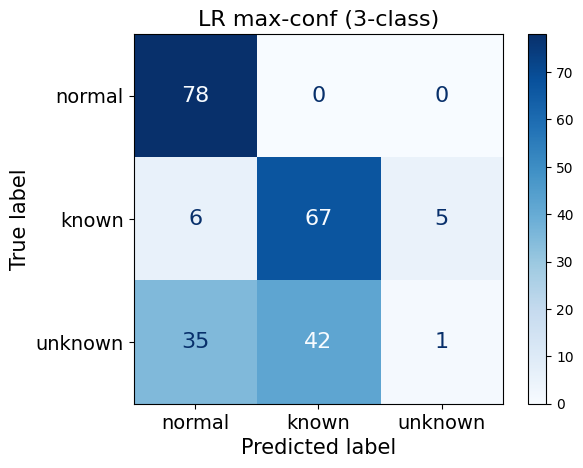

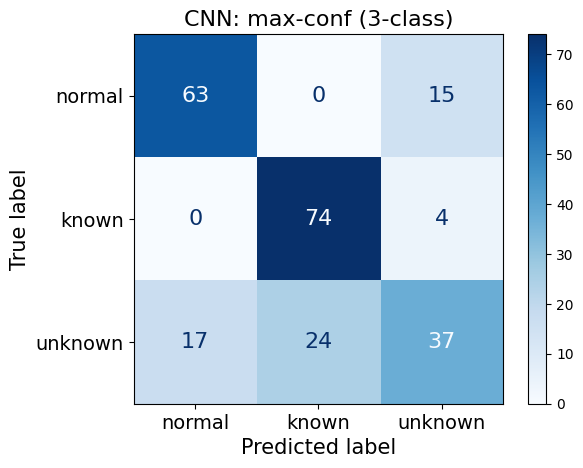

CNN: classical (normal vs known) confusion matrix: [[78  0]
 [ 0 78]]


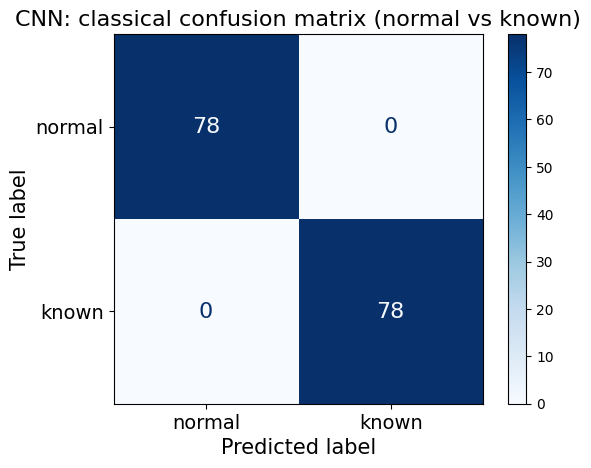

CNN: embeddings confusion matrix: [[ 35  43]
 [  0 156]]


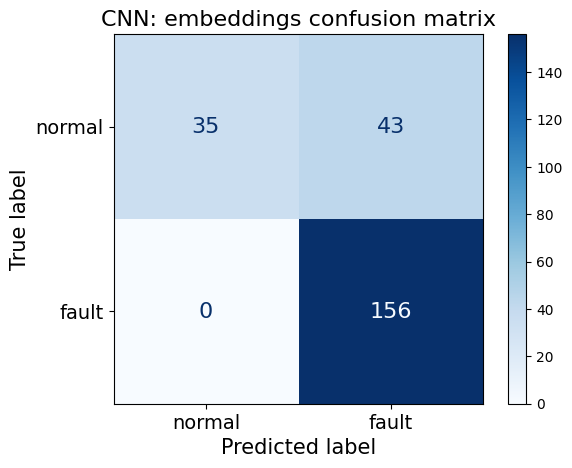

Test file counts (before balance):
  normal=2
  interfere=2
  blocked=10
Balancing test files to 2 per label


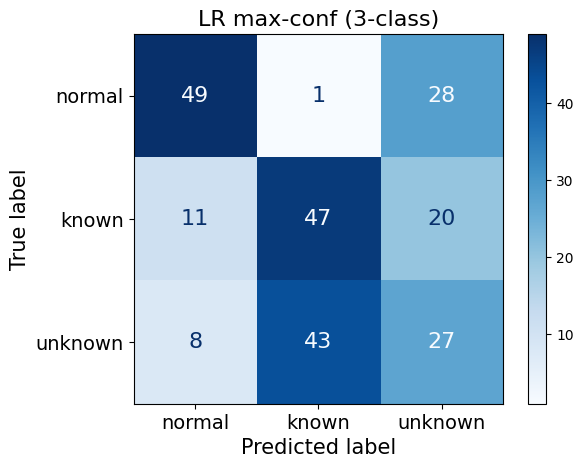

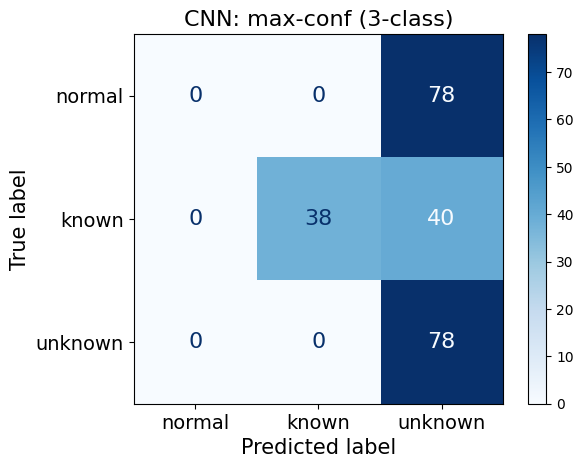

CNN: classical (normal vs known) confusion matrix: [[78  0]
 [39 39]]


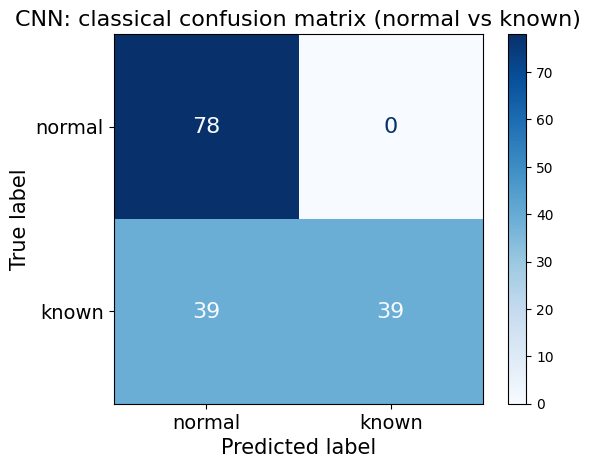

CNN: embeddings confusion matrix: [[  0  78]
 [  0 156]]


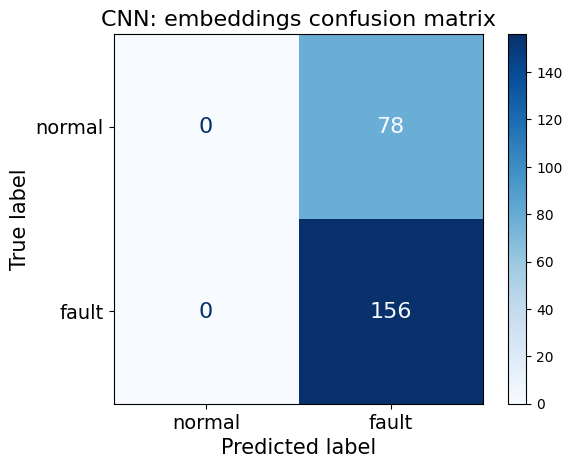

,method,accuracy,precision,recall,f1,false_positive_rate,group,scenario
0,B: centroid distance,0.666667,0.666667,1.000000,0.800000,1.000000,anomaly-only,"Train NORMAL+BLOCKED, Unseen INTERFERE"
1,D: AE + GMM,0.914530,0.930380,0.942308,0.936306,0.141026,anomaly-only,"Train NORMAL+BLOCKED, Unseen INTERFERE"
2,E: AE recon,0.880342,0.926667,0.891026,0.908497,0.141026,anomaly-only,"Train NORMAL+BLOCKED, Unseen INTERFERE"
3,F: SVDD (OCSVM),0.940171,0.927711,0.987179,0.956522,0.153846,anomaly-only,"Train NORMAL+BLOCKED, Unseen INTERFERE"
4,A: LR max-conf,0.824786,1.000000,0.737179,0.848708,0.000000,classifier-based,"Train NORMAL+BLOCKED, Unseen INTERFERE"
5,C: distance -> LR,0.615385,0.655660,0.891026,0.755435,0.935897,classifier-based,"Train NORMAL+BLOCKED, Unseen INTERFERE"
6,CNN: embeddings,0.816239,0.783920,1.000000,0.878873,0.551282,classifier-based,"Train NORMAL+BLOCKED, Unseen INTERFERE"
7,CNN: max-conf,0.863248,0.902597,0.891026,0.896774,0.192308,classifier-based,"Train NORMAL+BLOCKED, Unseen INTERFERE"
8,E*: AE recon (known->unknown),0.871795,0.980000,0.628205,0.765625,0.006410,unknown-detection,"Train NORMAL+BLOCKED, Unseen INTERFERE"
9,F*: SVDD (known->unknown),0.871795,0.980000,0.628205,0.765625,0.006410,unknown-detection,"Train NORMAL+BLOCKED, Unseen INTERFERE"


=== Train NORMAL+BLOCKED, Unseen INTERFERE ===
-- anomaly-only --


,method,accuracy,precision,recall,f1,false_positive_rate,group,scenario
0,B: centroid distance,0.666667,0.666667,1.000000,0.800000,1.000000,anomaly-only,"Train NORMAL+BLOCKED, Unseen INTERFERE"
1,D: AE + GMM,0.914530,0.930380,0.942308,0.936306,0.141026,anomaly-only,"Train NORMAL+BLOCKED, Unseen INTERFERE"
2,E: AE recon,0.880342,0.926667,0.891026,0.908497,0.141026,anomaly-only,"Train NORMAL+BLOCKED, Unseen INTERFERE"
3,F: SVDD (OCSVM),0.940171,0.927711,0.987179,0.956522,0.153846,anomaly-only,"Train NORMAL+BLOCKED, Unseen INTERFERE"


-- classifier-based --


,method,accuracy,precision,recall,f1,false_positive_rate,group,scenario
0,A: LR max-conf,0.824786,1.000000,0.737179,0.848708,0.000000,classifier-based,"Train NORMAL+BLOCKED, Unseen INTERFERE"
1,C: distance -> LR,0.615385,0.655660,0.891026,0.755435,0.935897,classifier-based,"Train NORMAL+BLOCKED, Unseen INTERFERE"
2,CNN: embeddings,0.816239,0.783920,1.000000,0.878873,0.551282,classifier-based,"Train NORMAL+BLOCKED, Unseen INTERFERE"
3,CNN: max-conf,0.863248,0.902597,0.891026,0.896774,0.192308,classifier-based,"Train NORMAL+BLOCKED, Unseen INTERFERE"


...

,method,accuracy,precision,recall,f1,false_positive_rate,group,scenario
0,B: centroid distance,0.666667,0.666667,1.000000,0.800000,1.000000,anomaly-only,"Train NORMAL+INTERFERE, Unseen BLOCKED"
1,D: AE + GMM,0.794872,0.928571,0.750000,0.829787,0.115385,anomaly-only,"Train NORMAL+INTERFERE, Unseen BLOCKED"
2,E: AE recon,0.803419,0.898551,0.794872,0.843537,0.179487,anomaly-only,"Train NORMAL+INTERFERE, Unseen BLOCKED"
3,F: SVDD (OCSVM),0.816239,0.912409,0.801282,0.853242,0.153846,anomaly-only,"Train NORMAL+INTERFERE, Unseen BLOCKED"


-- classifier-based --


,method,accuracy,precision,recall,f1,false_positive_rate,group,scenario
0,A: LR max-conf,0.794872,0.825301,0.878205,0.850932,0.371795,classifier-based,"Train NORMAL+INTERFERE, Unseen BLOCKED"
1,C: distance -> LR,0.649573,0.836364,0.589744,0.691729,0.230769,classifier-based,"Train NORMAL+INTERFERE, Unseen BLOCKED"
2,CNN: embeddings,0.666667,0.666667,1.000000,0.800000,1.000000,classifier-based,"Train NORMAL+INTERFERE, Unseen BLOCKED"
3,CNN: max-conf,0.666667,0.666667,1.000000,0.800000,1.000000,classifier-based,"Train NORMAL+INTERFERE, Unseen BLOCKED"


-- unknown-detection --


,method,accuracy,precision,recall,f1,false_positive_rate,group,scenario
0,E*: AE recon (known->unknown),0.572650,0.288462,0.192308,0.230769,0.237179,unknown-detection,"Train NORMAL+INTERFERE, Unseen BLOCKED"
1,F*: SVDD (known->unknown),0.568376,0.265306,0.166667,0.204724,0.230769,unknown-detection,"Train NORMAL+INTERFERE, Unseen BLOCKED"


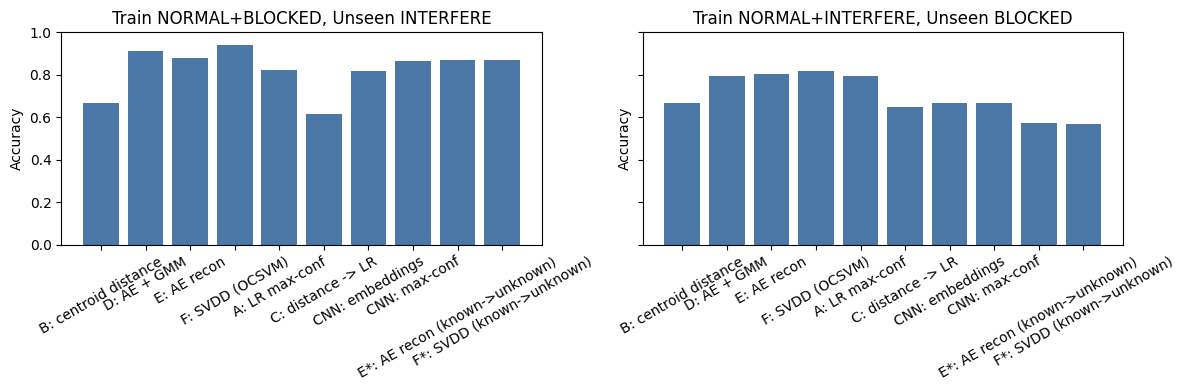

In [32]:
# Compare fault-detection accuracy across methods (seen vs unseen scenarios)

import copy
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# === Config ===
RUN_HEAVY_METHODS = True  # set False to skip AE+GMM and AE recon for faster runs
CONF_REJECT_Q = 0.01      # reject lowest 5% of known validation confidence as unknown
UNKNOWN_LABEL = -1


# === Data helpers ===

def _split_files(files, seed=SEED):
    if not files:
        return [], [], []
    trainval, test = train_test_split(files, test_size=TEST_RATIO, shuffle=True, random_state=seed)
    train, val = train_test_split(trainval, test_size=VAL_SPLIT, shuffle=True, random_state=seed)
    return train, val, test


def _prepare_windows(train_files, val_files, test_files):
    train_data = prepare_training_data(
        train_files, shuffle=True, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
    )
    val_data = prepare_training_data(
        val_files, shuffle=False, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
    )

    test_data = []
    for label, files in test_files.items():
        test_data.extend(
            prepare_training_data(
                {label: files}, shuffle=False, col_names=COLS, remove_first_second=REMOVE_FIRST_SECOND
            )
        )

    pre = RMSNorm()
    train_pre = pre.preprocess(train_data)
    val_pre = pre.preprocess(val_data)
    test_pre = pre.preprocess(test_data)

    return train_pre, val_pre, test_pre



def _balance_files_by_label(file_map, seed=SEED):
    # Subsample files per label to the same count (fair share).
    if not file_map:
        return file_map, {}, 0
    counts = {lbl: len(files) for lbl, files in file_map.items()}
    min_n = min(counts.values()) if counts else 0
    rng = np.random.default_rng(seed)
    balanced = {}
    for lbl, files in file_map.items():
        if len(files) > min_n:
            idx = rng.choice(len(files), size=min_n, replace=False)
            balanced[lbl] = [files[i] for i in idx]
        else:
            balanced[lbl] = list(files)
    return balanced, counts, min_n



def _stack_windows(windows, target_len=None):
    if len(windows) == 0:
        raise ValueError("No windows found.")

    if target_len is None:
        target_len = min(
            min(len(w.acc_x), len(w.acc_y), len(w.acc_z))
            for w in windows
        )

    X = np.empty((len(windows), 3, target_len), dtype=np.float32)
    y_raw = np.empty((len(windows),), dtype=np.int64)

    for i, w in enumerate(windows):
        X[i, 0] = np.asarray(w.acc_x, dtype=np.float32)[:target_len]
        X[i, 1] = np.asarray(w.acc_y, dtype=np.float32)[:target_len]
        X[i, 2] = np.asarray(w.acc_z, dtype=np.float32)[:target_len]
        y_raw[i] = int(w.label)

    return X, y_raw, target_len


# === Classifier confidence helpers (known vs unknown) ===

def _max_conf_threshold(probs, q=CONF_REJECT_Q):
    max_prob = probs.max(axis=1)
    return float(np.quantile(max_prob, q))


def _predict_known_or_unknown(probs, classes, conf_thr, unknown_label=UNKNOWN_LABEL):
    max_idx = np.argmax(probs, axis=1)
    max_prob = probs[np.arange(len(probs)), max_idx]
    pred_labels = np.asarray([classes[i] for i in max_idx], dtype=int)
    pred_labels[max_prob < conf_thr] = unknown_label
    return pred_labels, max_prob






def _to_three_class(labels, known_labels, normal_label=NORMAL_LABEL, unknown_label=UNKNOWN_LABEL):
    known_set = set(known_labels)
    out = np.empty(len(labels), dtype=int)
    for i, lbl in enumerate(labels):
        if lbl == normal_label:
            out[i] = 0
        elif lbl == unknown_label or lbl not in known_set:
            out[i] = 2
        else:
            out[i] = 1
    return out


def _style_confusion_matrix_plot(disp, title, value_font=16, tick_font=14, label_font=15, title_font=16):
    if getattr(disp, "text_", None) is not None:
        for t in np.ravel(disp.text_):
            if t is not None:
                t.set_fontsize(value_font)
    if getattr(disp, "ax_", None) is not None:
        disp.ax_.tick_params(axis="both", labelsize=tick_font)
        disp.ax_.set_xlabel(disp.ax_.get_xlabel(), fontsize=label_font)
        disp.ax_.set_ylabel(disp.ax_.get_ylabel(), fontsize=label_font)
        disp.ax_.set_title(title, fontsize=title_font)


def _plot_three_class_cm(y_true_labels, y_pred_labels, known_labels, title):
    y_true_3 = _to_three_class(y_true_labels, known_labels)
    y_pred_3 = _to_three_class(y_pred_labels, known_labels)
    cm = confusion_matrix(y_true_3, y_pred_3, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["normal", "known", "unknown"],
    )
    disp.plot(cmap="Blues", values_format="d")
    _style_confusion_matrix_plot(disp, title)
    plt.show()

def _to_fault_binary(pred_labels, normal_label=NORMAL_LABEL):
    return (pred_labels != normal_label).astype(int)


# === Feature-based methods ===

def _eval_methods_feature(train_pre, val_pre, test_pre):
    embedder = MLEmbedder2()

    X_train = embedder.embed(train_pre)
    X_val = embedder.embed(val_pre)
    X_test = embedder.embed(test_pre)

    y_train = np.array([w.label for w in train_pre], dtype=int)
    y_val = np.array([w.label for w in val_pre], dtype=int)
    y_test = np.array([w.label for w in test_pre], dtype=int)
    y_test_bin = make_binary_labels(y_test)

    known_labels = set(y_train.tolist())

    y_unknown_test = np.array([0 if y in known_labels else 1 for y in y_test], dtype=int)

    feat_select = globals().get("FEATURE_SELECTION", True)
    feat_method = globals().get("METHOD", "fisher")
    feat_ratio = globals().get("TOP_FEATURE_RATIO", 0.3)

    if feat_select:
        X_train_np = np.asarray(X_train)
        y_train_np = np.asarray(y_train)
        top_idx, _ = select_features(X_train_np, y_train_np, method=feat_method, ratio=feat_ratio)
        X_train = X_train_np[:, top_idx]
        X_val = np.asarray(X_val)[:, top_idx]
        X_test = np.asarray(X_test)[:, top_idx]

    # Precompute normal-only splits for anomaly-only methods
    X_train_norm = X_train[y_train == NORMAL_LABEL]
    X_val_norm = X_val[y_val == NORMAL_LABEL]

    results = []

    # --- Classifier-based methods ---
    classifier = globals().get("CLASSIFIER", "lr")
    if classifier.lower() == "svm":
        clf_a = make_pipeline(
            StandardScaler(),
            SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=SEED),
        )
        clf_name = "SVM"
        clf_step = "svc"
    else:
        clf_a = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
        )
        clf_name = "LR"
        clf_step = "logisticregression"

    clf_a.fit(X_train, y_train)
    probs_val = clf_a.predict_proba(X_val)
    probs_test = clf_a.predict_proba(X_test)
    classes = clf_a.named_steps[clf_step].classes_

    conf_thr = _max_conf_threshold(probs_val, q=CONF_REJECT_Q)
    pred_labels, _ = _predict_known_or_unknown(probs_test, classes, conf_thr)
    _plot_three_class_cm(y_test, pred_labels, known_labels, f"{clf_name} max-conf (3-class)")
    y_pred_a = _to_fault_binary(pred_labels)
    results.append(eval_method(f"A: {clf_name} max-conf", y_test_bin, y_pred_a, group="classifier-based"))

    # Method C: distance-to-centroid -> LR (binary classifier)
    scaler_b = StandardScaler().fit(X_train_norm)
    X_train_norm_s = scaler_b.transform(X_train_norm)
    centroid = X_train_norm_s.mean(axis=0)

    def dist_to_centroid(X):
        Xs = scaler_b.transform(X)
        return np.linalg.norm(Xs - centroid, axis=1)

    train_dist = dist_to_centroid(X_train).reshape(-1, 1)
    val_dist = dist_to_centroid(X_val).reshape(-1, 1)
    test_dist = dist_to_centroid(X_test).reshape(-1, 1)

    train_bin = make_binary_labels(y_train)
    val_bin = make_binary_labels(y_val)

    clf_c = LogisticRegression(class_weight="balanced", random_state=SEED)
    clf_c.fit(train_dist, train_bin)

    scores_val_c = clf_c.predict_proba(val_dist)[:, 1]
    thr_c, _ = find_best_threshold(scores_val_c, val_bin, anomaly_if_low=False)

    scores_test_c = clf_c.predict_proba(test_dist)[:, 1]
    y_pred_c = (scores_test_c > thr_c).astype(int)
    results.append(eval_method("C: distance -> LR", y_test_bin, y_pred_c, group="classifier-based"))

    # --- Anomaly-only methods (trained on normal only) ---
    DIST_Q = 0.95
    val_dist_norm = dist_to_centroid(X_val_norm)
    thr_b = float(np.quantile(val_dist_norm, DIST_Q))

    test_dist = dist_to_centroid(X_test)
    y_pred_b = (test_dist > thr_b).astype(int)
    results.append(eval_method("B: centroid distance", y_test_bin, y_pred_b, group="anomaly-only"))

    SVDD_KERNEL = "rbf"
    SVDD_NU = 0.05
    SVDD_GAMMA = "scale"
    SVDD_Q = 0.95

    X_train_norm_s = scaler_b.transform(X_train_norm)
    X_val_norm_s = scaler_b.transform(X_val_norm)
    X_test_s = scaler_b.transform(X_test)

    svdd = OneClassSVM(kernel=SVDD_KERNEL, nu=SVDD_NU, gamma=SVDD_GAMMA)
    svdd.fit(X_train_norm_s)

    val_scores_f = -svdd.decision_function(X_val_norm_s).ravel()
    thr_f = float(np.quantile(val_scores_f, SVDD_Q))

    test_scores_f = -svdd.decision_function(X_test_s).ravel()
    y_pred_f = (test_scores_f > thr_f).astype(int)
    results.append(eval_method("F: SVDD (OCSVM)", y_test_bin, y_pred_f, group="anomaly-only"))

    # --- Unknown detection (trained on all known classes) ---
    SVDD_Q_K = 0.95

    scaler_k = StandardScaler().fit(X_train)
    X_train_k = scaler_k.transform(X_train)
    X_val_k = scaler_k.transform(X_val)
    X_test_k = scaler_k.transform(X_test)

    svdd_k = OneClassSVM(kernel=SVDD_KERNEL, nu=SVDD_NU, gamma=SVDD_GAMMA)
    svdd_k.fit(X_train_k)

    val_scores_k = -svdd_k.decision_function(X_val_k).ravel()
    thr_k = float(np.quantile(val_scores_k, SVDD_Q_K))

    test_scores_k = -svdd_k.decision_function(X_test_k).ravel()
    y_pred_unknown_k = (test_scores_k > thr_k).astype(int)
    results.append(eval_method("F*: SVDD (known->unknown)", y_unknown_test, y_pred_unknown_k, group="unknown-detection"))

    if RUN_HEAVY_METHODS:
        # Method D/E: AE + GMM, AE recon (normal only)
        scaler_d = StandardScaler().fit(X_train_norm)
        X_train_norm_s = scaler_d.transform(X_train_norm)
        X_val_norm_s = scaler_d.transform(X_val_norm)
        X_test_s = scaler_d.transform(X_test)

        input_dim = X_train_norm_s.shape[1]
        latent_dim = min(16, max(4, input_dim // 4))

        class FeatureAutoencoder(nn.Module):
            def __init__(self, in_dim, z_dim):
                super().__init__()
                self.encoder = nn.Sequential(
                    nn.Linear(in_dim, 64),
                    nn.ReLU(),
                    nn.Linear(64, z_dim),
                )
                self.decoder = nn.Sequential(
                    nn.Linear(z_dim, 64),
                    nn.ReLU(),
                    nn.Linear(64, in_dim),
                )

            def forward(self, x):
                z = self.encoder(x)
                x_hat = self.decoder(z)
                return x_hat, z

        def train_ae(x_train, epochs=30, batch_size=256, lr=1e-3):
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            model = FeatureAutoencoder(input_dim, latent_dim).to(device)
            ds = TensorDataset(torch.from_numpy(x_train).float())
            loader = DataLoader(ds, batch_size=batch_size, shuffle=True)
            opt = torch.optim.Adam(model.parameters(), lr=lr)
            loss_fn = nn.MSELoss()

            for epoch in range(1, epochs + 1):
                model.train()
                losses = []
                for (batch,) in loader:
                    batch = batch.to(device)
                    opt.zero_grad()
                    recon, _ = model(batch)
                    loss = loss_fn(recon, batch)
                    loss.backward()
                    opt.step()
                    losses.append(loss.item())
            return model

        def encode(model, x_np):
            device = next(model.parameters()).device
            with torch.no_grad():
                x_t = torch.from_numpy(x_np).float().to(device)
                _, z = model(x_t)
            return z.cpu().numpy()

        ae = train_ae(X_train_norm_s, epochs=30)

        Z_train = encode(ae, X_train_norm_s)
        Z_val = encode(ae, X_val_norm_s)
        Z_test = encode(ae, X_test_s)

        gmm = GaussianMixture(n_components=5, covariance_type="full", random_state=SEED)
        gmm.fit(Z_train)

        val_scores = -gmm.score_samples(Z_val)
        D_Q = 0.954
        thr_d = float(np.quantile(val_scores, D_Q))

        test_scores = -gmm.score_samples(Z_test)
        y_pred_d = (test_scores > thr_d).astype(int)
        results.append(eval_method("D: AE + GMM", y_test_bin, y_pred_d, group="anomaly-only"))

        def recon_error(model, x_np):
            device = next(model.parameters()).device
            with torch.no_grad():
                x_t = torch.from_numpy(x_np).float().to(device)
                recon, _ = model(x_t)
                err = ((recon - x_t) ** 2).mean(dim=1)
            return err.cpu().numpy()

        AE_Q = 0.954
        val_err = recon_error(ae, X_val_norm_s)
        thr_e = float(np.quantile(val_err, AE_Q))

        test_err = recon_error(ae, X_test_s)
        y_pred_e = (test_err > thr_e).astype(int)
        results.append(eval_method("E: AE recon", y_test_bin, y_pred_e, group="anomaly-only"))

        # AE recon trained on all known classes (unknown detection)
        scaler_k_ae = StandardScaler().fit(X_train)
        X_train_k_s = scaler_k_ae.transform(X_train)
        X_val_k_s = scaler_k_ae.transform(X_val)
        X_test_k_s = scaler_k_ae.transform(X_test)

        ae_known = train_ae(X_train_k_s, epochs=30)

        AE_Q_K = 0.954
        val_err_k = recon_error(ae_known, X_val_k_s)
        thr_k_e = float(np.quantile(val_err_k, AE_Q_K))

        test_err_k = recon_error(ae_known, X_test_k_s)
        y_pred_unknown_e = (test_err_k > thr_k_e).astype(int)
        results.append(eval_method("E*: AE recon (known->unknown)", y_unknown_test, y_pred_unknown_e, group="unknown-detection"))

    return results


# === CNN-based methods ===

def _eval_methods_cnn(train_pre, val_pre, test_pre):
    X_train_raw, y_train_raw, target_len = _stack_windows(train_pre)
    X_val_raw, y_val_raw, _ = _stack_windows(val_pre, target_len=target_len)
    X_test_raw, y_test_raw, _ = _stack_windows(test_pre, target_len=target_len)

    mean = X_train_raw.mean(axis=(0, 2), keepdims=True)
    std = X_train_raw.std(axis=(0, 2), keepdims=True) + 1e-6

    X_train = (X_train_raw - mean) / std
    X_val = (X_val_raw - mean) / std
    X_test = (X_test_raw - mean) / std

    # Label encoding for TRAIN/VAL only (unseen faults are excluded from classifier heads)
    all_labels = sorted(set(y_train_raw.tolist()) | set(y_val_raw.tolist()))
    label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
    idx_to_label = {idx: label for label, idx in label_to_idx.items()}

    y_train = np.array([label_to_idx[int(y)] for y in y_train_raw], dtype=np.int64)
    y_val = np.array([label_to_idx[int(y)] for y in y_val_raw], dtype=np.int64)

    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

    class Fan1DCNN(nn.Module):
        def __init__(self, n_classes: int, in_channels: int = 3):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
                nn.BatchNorm1d(32),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(kernel_size=2),

                nn.Conv1d(32, 64, kernel_size=5, padding=2),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(kernel_size=2),

                nn.Conv1d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm1d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(kernel_size=2),

                nn.Conv1d(128, 128, kernel_size=3, padding=1),
                nn.BatchNorm1d(128),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool1d(1),
            )
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(128, 64),
                nn.ReLU(inplace=True),
                nn.Dropout(p=0.3),
                nn.Linear(64, n_classes),
            )

        def forward(self, x):
            x = self.features(x)
            return self.classifier(x)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(label_to_idx)
    model = Fan1DCNN(n_classes=num_classes).to(device)

    counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)
    class_weights = counts.sum() / np.maximum(counts * num_classes, 1.0)
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)

    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    EPOCHS = 40
    EARLY_STOP_PATIENCE = 8

    @torch.no_grad()
    def evaluate(loader):
        model.eval()
        total_loss = 0.0
        all_pred = []
        all_true = []

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * yb.size(0)

            pred = torch.argmax(logits, dim=1)
            all_pred.append(pred.cpu().numpy())
            all_true.append(yb.cpu().numpy())

        y_true = np.concatenate(all_true)
        y_pred = np.concatenate(all_pred)
        avg_loss = total_loss / len(loader.dataset)
        acc = accuracy_score(y_true, y_pred)
        return avg_loss, acc

    def train_one_epoch(loader):
        model.train()
        total_loss = 0.0

        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * yb.size(0)

        return total_loss / len(loader.dataset)

    best_state = None
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(train_loader)
        val_loss, _ = evaluate(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= EARLY_STOP_PATIENCE:
                break

    if best_state is None:
        raise RuntimeError("Training did not produce a valid model state.")

    model.load_state_dict(best_state)

    def predict_probs(X_np, batch_size=512):
        model.eval()
        probs = []
        with torch.no_grad():
            for i in range(0, len(X_np), batch_size):
                xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
                logits = model(xb)
                p = torch.softmax(logits, dim=1).cpu().numpy()
                probs.append(p)
        return np.vstack(probs)

    def extract_embeddings(X_np, batch_size=512):
        model.eval()
        embs = []
        with torch.no_grad():
            for i in range(0, len(X_np), batch_size):
                xb = torch.from_numpy(X_np[i:i+batch_size]).float().to(device)
                z = model.features(xb).squeeze(-1)
                embs.append(z.cpu().numpy())
        return np.vstack(embs)

    probs_val = predict_probs(X_val)
    probs_test = predict_probs(X_test)

    y_test_bin = make_binary_labels(y_test_raw)

    known_labels = set(y_train_raw.tolist())

    # Classifier confidence (known vs unknown in one pass)
    classes = np.array([idx_to_label[i] for i in range(num_classes)], dtype=int)
    conf_thr = _max_conf_threshold(probs_val, q=CONF_REJECT_Q)
    pred_labels, _ = _predict_known_or_unknown(probs_test, classes, conf_thr)
    _plot_three_class_cm(y_test_raw, pred_labels, known_labels, "CNN: max-conf (3-class)")
    y_pred_conf = _to_fault_binary(pred_labels)

    # Classical classifier view: normal vs known (exclude unseen/unknown labels)
    known_mask = np.isin(y_test_raw, list(known_labels))
    if known_mask.any():
        y_true_known_bin = (y_test_raw[known_mask] != NORMAL_LABEL).astype(int)
        pred_idx = np.argmax(probs_test[known_mask], axis=1)
        pred_labels_known = np.asarray([classes[i] for i in pred_idx], dtype=int)
        y_pred_known_bin = (pred_labels_known != NORMAL_LABEL).astype(int)

        cm_known = confusion_matrix(y_true_known_bin, y_pred_known_bin, labels=[0, 1])
        print("CNN: classical (normal vs known) confusion matrix:", cm_known)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm_known, display_labels=["normal", "known"])
        disp.plot(cmap="Blues", values_format="d")
        _style_confusion_matrix_plot(disp, "CNN: classical confusion matrix (normal vs known)")
        plt.show()

    # Embedding distance (centroid on normal only)
    emb_train = extract_embeddings(X_train)
    emb_val = extract_embeddings(X_val)
    emb_test = extract_embeddings(X_test)

    emb_train_norm = emb_train[y_train_raw == NORMAL_LABEL]
    emb_val_norm = emb_val[y_val_raw == NORMAL_LABEL]

    scaler_emb = StandardScaler().fit(emb_train_norm)
    emb_train_norm_s = scaler_emb.transform(emb_train_norm)
    emb_val_norm_s = scaler_emb.transform(emb_val_norm)
    emb_test_s = scaler_emb.transform(emb_test)

    centroid = emb_train_norm_s.mean(axis=0)

    def dist_to_centroid_emb(Z):
        return np.linalg.norm(Z - centroid, axis=1)

    EMB_Q = 0.9
    val_dist = dist_to_centroid_emb(emb_val_norm_s)
    thr_emb = float(np.quantile(val_dist, EMB_Q))

    test_dist = dist_to_centroid_emb(emb_test_s)
    y_pred_emb = (test_dist > thr_emb).astype(int)

    print("CNN: embeddings confusion matrix:", confusion_matrix(y_test_bin, y_pred_emb))

    cm = confusion_matrix(y_test_bin, y_pred_emb)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["normal", "fault"])
    disp.plot(cmap="Blues", values_format="d")
    _style_confusion_matrix_plot(disp, "CNN: embeddings confusion matrix")
    plt.show()

    results = []
    results.append(eval_method("CNN: max-conf", y_test_bin, y_pred_conf, group="classifier-based"))
    results.append(eval_method("CNN: embeddings", y_test_bin, y_pred_emb, group="classifier-based"))

    return results


# === Scenario runner ===

def run_scenario(name, seen_faults, unseen_faults):
    # Split files per class
    normal_train, normal_val, normal_test = _split_files(buckets["normal"], seed=SEED)

    seen_splits = {}
    for fault in seen_faults:
        seen_splits[fault] = _split_files(buckets[fault], seed=SEED)

    # Build file maps (train/val exclude unseen faults)
    train_files = {LABELS["normal"]: normal_train}
    val_files = {LABELS["normal"]: normal_val}
    test_files = {LABELS["normal"]: normal_test}

    for fault, (tr, va, te) in seen_splits.items():
        train_files[LABELS[fault]] = tr
        val_files[LABELS[fault]] = va
        test_files[LABELS[fault]] = te

    # Add unseen faults to test set, then balance files per label
    for fault in unseen_faults:
        test_files[LABELS[fault]] = buckets[fault]

    balanced_test_files, test_counts, min_n = _balance_files_by_label(test_files, seed=SEED)
    print("Test file counts (before balance):")
    for lbl, cnt in test_counts.items():
        print(f"  {LABEL_NAMES[lbl]}={cnt}")
    if min_n > 0:
        print(f"Balancing test files to {min_n} per label")

    train_pre, val_pre, test_pre = _prepare_windows(train_files, val_files, balanced_test_files)

    results = []
    for r in _eval_methods_feature(train_pre, val_pre, test_pre):
        r["scenario"] = name
        results.append(r)
    for r in _eval_methods_cnn(train_pre, val_pre, test_pre):
        r["scenario"] = name
        results.append(r)

    return results


SCENARIOS = [
    {
        "name": "Train NORMAL+BLOCKED, Unseen INTERFERE",
        "seen": ["blocked"],
        "unseen": ["interfere"],
    },
    {
        "name": "Train NORMAL+INTERFERE, Unseen BLOCKED",
        "seen": ["interfere"],
        "unseen": ["blocked"],
    },
]

all_results = []
for s in SCENARIOS:
    # Skip scenarios if required files are missing
    if any(len(buckets[f]) == 0 for f in s["seen"] + s["unseen"]):
        print(f"Skipping {s['name']} (missing files)")
        continue
    all_results.extend(run_scenario(s["name"], s["seen"], s["unseen"]))

results_df = pd.DataFrame(all_results)
if results_df.empty:
    print("No results to display. Check data availability.")
else:
    results_df = results_df.sort_values(["scenario", "group", "method"]).reset_index(drop=True)

    display(results_df)

    # Plot split by scenario and show per-scenario tables
    scenarios = sorted(results_df["scenario"].unique())

    for scen in scenarios:
        sub = results_df[results_df["scenario"] == scen].reset_index(drop=True)
        print(f"=== {scen} ===")
        for grp in ["anomaly-only", "classifier-based", "unknown-detection"]:
            grp_sub = sub[sub["group"] == grp].reset_index(drop=True)
            if not grp_sub.empty:
                print(f"-- {grp} --")
                display(grp_sub)

    fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 4), sharey=True)
    if len(scenarios) == 1:
        axes = [axes]

    for ax, scen in zip(axes, scenarios):
        sub = results_df[results_df["scenario"] == scen]
        ax.bar(sub["method"], sub["accuracy"], color="#4C78A8")
        ax.set_title(scen)
        ax.set_ylim(0, 1)
        ax.set_ylabel("Accuracy")
        ax.tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()
